# Manifest explorer

The generator does not write audio. It writes a **manifest**: one CSV row per trial, holding every random choice that trial needs - which speakers, which recordings, when each one starts talking, how loud, which room, which noise clip. A renderer reads a row and produces exactly one mixture from it.

This notebook reads a manifest and explains what is in it, one theme at a time, so the recipe is understood before any audio exists.

Point `SPLIT` at any manifest in `data/manifests/` and re-run. Nothing below is specific to one split.

In [39]:
from pathlib import Path
from types import SimpleNamespace
import hashlib

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

## 0. Setup

Loads four things for the chosen split:

| | |
|---|---|
| **manifest** | `data/manifests/<split>.csv` — the trials |
| **meta** | `<split>.meta.yaml` — when it was built, from which commit and seed |
| **generator settings** | the `defaults` + this split's overrides from the config, so we can check the manifest against the ranges it was told to sample |
| **indexes** | `data/index/` — every LibriSpeech utterance (speaker, duration, transcript) and every noise clip. The manifest stores only IDs, so durations and text are looked up here |

In [64]:
# Which manifest to analyse. Works for smoke_train, smoke_val, train, val,
# eval_public, eval_private, or a scratch manifest via MANIFEST_PATH.

SPLIT = "smoke_val"
MANIFEST_PATH = None      # full path to a .csv; overrides SPLIT when set

In [65]:

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 100)

# The generator packs multi-value fields as "a|b|c". These become real lists.
LIST_COLS = {
    "target_utts": "target_utt_list",
    "target_onsets_s": "target_onset_list",
    "interferer_utts": "interferer_utt_list",
    "interferer_onsets_s": "interferer_onset_list",
}

# Columns pandas must NOT type-infer.
#   IDs: "0090" would become the int 90 and stop matching the folder on disk.
#   Packed fields: if no row in a manifest happens to contain a "|", the column
#   looks numeric and is read as float64 -- then the parse below sees a float
#   instead of a string and yields [] for every row, silently dropping every
#   onset. Content-dependent dtypes break when the content changes.
STR_COLS = {c: str for c in [
    "target_speaker", "interferer_speaker", "target_chapter", "interferer_chapter",
    *LIST_COLS,
]}


def find_root(start=None):
    """Walk up until CLAUDE.md appears, so paths resolve whether the kernel
    started in src/exploratory/ or at the repo root."""
    here = (start or Path.cwd()).resolve()
    for d in [here, *here.parents]:
        if (d / "CLAUDE.md").exists():
            return d
    raise RuntimeError(f"repo root not found above {here}")


ROOT = find_root()


def _as_list(cell):
    """"a|b" -> ["a", "b"]. Empty or missing -> []. Target-absent trials
    genuinely have no target utterances, so [] is a real value, not a bug."""
    if not isinstance(cell, str) or not cell.strip():
        return []
    return cell.split("|")


def load(split, manifest_path=None):
    """Everything needed to analyse one split, bundled together."""
    man = Path(manifest_path) if manifest_path else ROOT / "data/manifests" / f"{split}.csv"
    df = pd.read_csv(man, dtype=STR_COLS)
    columns = list(df.columns)

    for raw, parsed in LIST_COLS.items():
        vals = df[raw].map(_as_list)
        df[parsed] = vals if raw.endswith("_utts") else vals.map(
            lambda v: [float(x) for x in v])
        # A populated field that parsed to nothing means the parse is broken,
        # not that the trial is empty. Fail loudly rather than analyse zeros.
        broke = df[raw].notna() & (df[parsed].str.len() == 0)
        assert not broke.any(), f"{raw}: {int(broke.sum())} rows failed to parse"

    # One onset per utterance, or the two lists cannot be zipped meaningfully.
    for who in ("target", "interferer"):
        assert (df[f"{who}_utt_list"].str.len()
                == df[f"{who}_onset_list"].str.len()).all(), f"{who}: length mismatch"

    meta = yaml.safe_load(man.with_suffix(".meta.yaml").read_text())

    cfg_file = ROOT / meta["config"]
    config = yaml.safe_load(cfg_file.read_text())
    cfg = {**config["defaults"], **config["splits"].get(split, {})}
    cfg["seed"], cfg["sample_rate"] = config["seed"], config["sample_rate"]
    # If the config changed after the manifest was written, the ranges we check
    # against are not the ranges that were actually sampled from.
    stale = hashlib.md5(cfg_file.read_bytes()).hexdigest() != meta.get("config_md5")

    idx = ROOT / "data/index"
    utt_file = idx / f"utterances_{split}.csv"
    utts = (pd.read_csv(utt_file, dtype={"speaker": str, "chapter": str}).set_index("utt")
            if utt_file.exists() else None)
    noise_file = idx / f"noise_{cfg['noise_split']}.csv"
    noise = pd.read_csv(noise_file).set_index("clip") if noise_file.exists() else None

    # Onsets alone do not say when a speaker stops. Attach each chosen
    # utterance's length so talking intervals can be reconstructed.
    if utts is not None:
        dur = utts["duration"].to_dict()
        for who in ("target", "interferer"):
            df[f"{who}_dur_list"] = df[f"{who}_utt_list"].map(
                lambda us: [dur[u] for u in us])

    return SimpleNamespace(split=split, path=man, df=df, columns=columns,
                           meta=meta, cfg=cfg, utts=utts, noise=noise,
                           config_stale=stale)


def spans(row, who):
    """When `who` is actually talking, as [(start_s, end_s), ...]."""
    return [(o, o + d) for o, d in
            zip(row[f"{who}_onset_list"], row[f"{who}_dur_list"])]


def text_of(D, row, who):
    """The words spoken by `who` in this trial, in order."""
    return " ".join(D.utts.loc[u, "text"] for u in row[f"{who}_utt_list"])

In [66]:
D = load(SPLIT, MANIFEST_PATH)

print(f"{D.path.relative_to(ROOT)}")
print(f"  {len(D.df)} trials, {len(D.columns)} columns")
print(f"  built {D.meta['generated']}  seed {D.meta['seed']}  "
      f"commit {D.meta['git_commit'][:7]}  unsatisfiable {D.meta['n_failed']}")
print(f"  generator {D.meta['config']}"
      + ("   ** CHANGED since build — ranges below may not match **"
         if D.config_stale else "   (unchanged since build)"))
print(f"  utterance index  {'loaded' if D.utts is not None else 'MISSING'}"
      f"   ({len(D.utts)} utterances)" if D.utts is not None else "")
print(f"  noise index      {'loaded' if D.noise is not None else 'MISSING'}"
      f"   ({len(D.noise)} clips, WHAM! split '{D.cfg['noise_split']}')"
      if D.noise is not None else "")

data/manifests/smoke_val.csv
  20 trials, 41 columns
  built 2026-08-10  seed 42  commit 9d1c68b  unsatisfiable 0
  generator experiments/configs/generator.yaml   (unchanged since build)
  utterance index  loaded   (367 utterances)
  noise index      loaded   (5000 clips, WHAM! split 'cv')


## 1. What each row does

### 1.1  `trial_id`

Each trial generated by the manifest can be replaced/regenerated. Secondly, since the manifest made use of `blake2b` instead of `hash()`, we are guaranteed to get identical data between different authors/users of the repository. Note that the 6 digit number at the end of the `trial_id` is NOT the row number, it is 

In [67]:
D.df.head(10)

,trial_id,split,target_speaker,target_chapter,target_utts,target_onsets_s,target_speech_s,target_activity,interferer_speaker,interferer_chapter,interferer_utts,interferer_onsets_s,interferer_speech_s,interferer_activity,enrollment_utt,enrollment_offset_s,enrollment_length_s,enrollment_eq,noise_clip,noise_offset_s,mixture_length_s,sir_db,snr_db,target_loudness_lufs,overlap_requested,overlap_achieved,t60_s,room_l,room_w,room_h,mic_x,mic_y,mic_z,target_x,target_y,target_z,interferer_x,interferer_y,interferer_z,target_absent,same_gender,target_utt_list,target_onset_list,interferer_utt_list,interferer_onset_list,target_dur_list,interferer_dur_list
0,smoke_val-42-000000,smoke_val,5694,64029,5694-64029-0006|5694-64029-0007,0.1260|9.1494,13.855,0.8018,1993,147965,1993-147965-0006,0.2330,8.830,0.5110,5694-64025-0019,1.0519,5.0,1,20rc010d_1.574_20mc0101_-1.574.flac,3.1831,17.281,3.07,15.51,-32.78,0.4145,0.4145,0.4099,7.258,7.211,3.305,2.587,3.462,1.682,3.915,4.311,1.242,3.134,4.289,1.582,0,0,"[5694-64029-0006, 5694-64029-0007]","[0.126, 9.1494]",[1993-147965-0006],[0.233],"[7.27, 6.585]",[8.83]
1,smoke_val-42-000001,smoke_val,6313,66125,6313-66125-0007|6313-66125-0008|6313-66125-0009,0.2427|6.5299|11.8883,12.130,0.7787,1993,147965,1993-147965-0001|1993-147965-0002,2.8409|5.5259,12.045,0.7733,6313-66129-0008,0.0315,5.0,1,01ua0106_1.115_012o0311_-1.115.flac,0.6912,15.576,-1.28,14.60,-29.70,0.6120,0.6119,0.3049,6.120,6.786,3.903,2.901,2.841,1.379,3.322,1.262,1.605,2.324,2.458,1.451,0,1,"[6313-66125-0007, 6313-66125-0008, 6313-66125-...","[0.2427, 6.5299, 11.8883]","[1993-147965-0001, 1993-147965-0002]","[2.8409, 5.5259]","[4.93, 4.49, 2.71]","[2.685, 9.36]"
2,smoke_val-42-000002,smoke_val,6241,61943,6241-61943-0009|6241-61943-0010|6241-61943-0011,0.2956|4.8976|11.7031,12.275,0.7860,6313,66125,6313-66125-0013|6313-66125-0014,5.3637|7.4237,5.845,0.3743,6241-61946-0000,0.8518,5.0,1,40ao0301_2.0914_01ac021a_-2.0914.flac,3.9286,15.617,13.59,5.20,-27.38,0.2602,0.2602,0.2717,7.465,8.706,3.792,3.290,4.592,1.499,2.967,3.495,0.916,3.178,3.798,1.616,0,0,"[6241-61943-0009, 6241-61943-0010, 6241-61943-...","[0.2956, 4.8976, 11.7031]","[6313-66125-0013, 6313-66125-0014]","[5.3637, 7.4237]","[3.845, 4.53, 3.9]","[2.06, 3.785]"
3,smoke_val-42-000003,smoke_val,5694,64025,5694-64025-0011|5694-64025-0012|5694-64025-0013,0.4195|8.1999|12.5930,13.345,0.8071,2078,142845,2078-142845-0018|2078-142845-0019,1.7998|7.1298,14.735,0.8911,5694-64029-0006,0.7883,5.0,0,01ua0103_2.0632_20ec010i_-2.0632.flac,0.7897,16.535,-1.52,5.47,-30.61,0.6980,0.7236,0.4040,5.590,5.713,3.768,2.621,3.286,1.513,1.763,2.148,1.649,2.994,4.579,0.995,0,1,"[5694-64025-0011, 5694-64025-0012, 5694-64025-...","[0.4195, 8.1999, 12.593]","[2078-142845-0018, 2078-142845-0019]","[1.7998, 7.1298]","[7.03, 2.875, 3.44]","[5.33, 9.405]"
4,smoke_val-42-000004,smoke_val,5694,64029,5694-64029-0001|5694-64029-0002|5694-64029-000...,0.0152|5.3306|8.3071|14.0574,14.915,0.8332,6241,66616,6241-66616-0019|6241-66616-0020,3.7200|10.0350,9.220,0.5151,5694-64025-0023,1.2755,5.0,1,014c0208_2.3161_028a010r_-2.3161.flac,6.8502,17.900,6.12,11.24,-28.39,0.4386,0.4388,0.4026,5.228,8.172,3.960,3.375,4.429,1.320,4.863,3.330,1.246,2.244,5.934,1.373,0,1,"[5694-64029-0001, 5694-64029-0002, 5694-64029-...","[0.0152, 5.3306, 8.3071, 14.0574]","[6241-66616-0019, 6241-66616-0020]","[3.72, 10.035]","[4.93, 2.645, 3.985, 3.355]","[6.315, 2.905]"
5,smoke_val-42-000005,smoke_val,6241,61946,6241-61946-0020|6241-61946-0021,2.0100|15.3586,16.410,0.8212,2078,142845,2078-142845-0050,0.0000,7.725,0.3866,6241-66616-0019,1.0889,5.0,0,014c0208_2.0946_01qo030w_-2.0946.flac,4.6987,19.984,0.95,15.40,-28.37,0.2854,0.2860,0.3674,5.646,9.577,3.684,2.006,5.084,1.282,2.604,4.715,1.271,2.710,3.958,1.522,0,1,"[6241-61946-0020, 6241-61946-0021]","[2.01, 15.3586]",[2078-142845-0050],[0.0],"[11.955, 4.455]",[7.725]
6,smoke_val-42-000006,smoke_val,1993,147964,1993-147964-0003|1993-147964-0004,1.5557|8.2997,11.985,0.7678,2078,142845,2078-142845-0013,1.3557,

In [68]:
print(f"  target speaker IDs: {D.df['target_speaker'].nunique()} "
      f"({D.df['target_speaker'].unique()})")

  target speaker IDs: 4 (<StringArray>
['5694', '6313', '6241', '1993']
Length: 4, dtype: str)


In [69]:
D.df.columns

Index(['trial_id', 'split', 'target_speaker', 'target_chapter', 'target_utts', 'target_onsets_s', 'target_speech_s', 'target_activity', 'interferer_speaker', 'interferer_chapter', 'interferer_utts',
       'interferer_onsets_s', 'interferer_speech_s', 'interferer_activity', 'enrollment_utt', 'enrollment_offset_s', 'enrollment_length_s', 'enrollment_eq', 'noise_clip', 'noise_offset_s',
       'mixture_length_s', 'sir_db', 'snr_db', 'target_loudness_lufs', 'overlap_requested', 'overlap_achieved', 't60_s', 'room_l', 'room_w', 'room_h', 'mic_x', 'mic_y', 'mic_z', 'target_x',
       'target_y', 'target_z', 'interferer_x', 'interferer_y', 'interferer_z', 'target_absent', 'same_gender', 'target_utt_list', 'target_onset_list', 'interferer_utt_list', 'interferer_onset_list',
       'target_dur_list', 'interferer_dur_list'],
      dtype='str')

Number of samples: 20


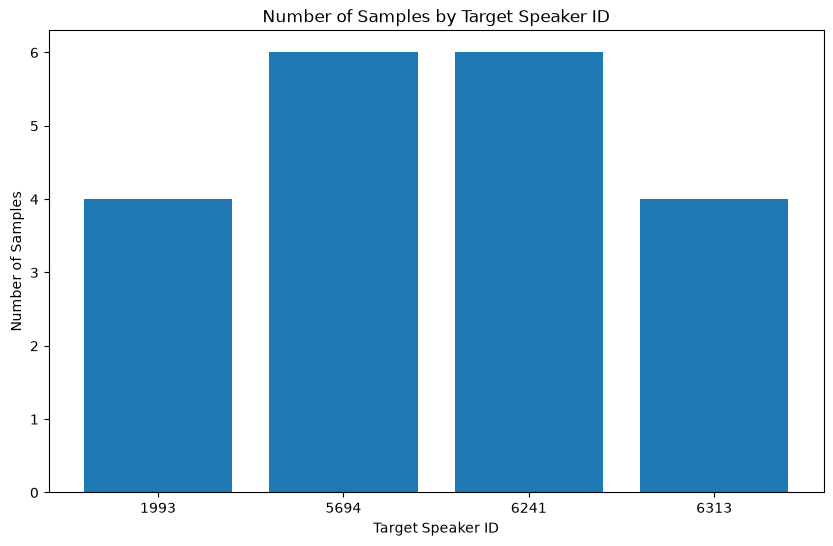

In [70]:
print(f"Number of samples: {len(D.df)}")
number_by_target_speaker = D.df.groupby('target_speaker').size().to_dict()
plt.figure(figsize=(10, 6))
plt.bar(number_by_target_speaker.keys(), number_by_target_speaker.values())
plt.xlabel('Target Speaker ID')
plt.ylabel('Number of Samples')
plt.title('Number of Samples by Target Speaker ID')
plt.show()

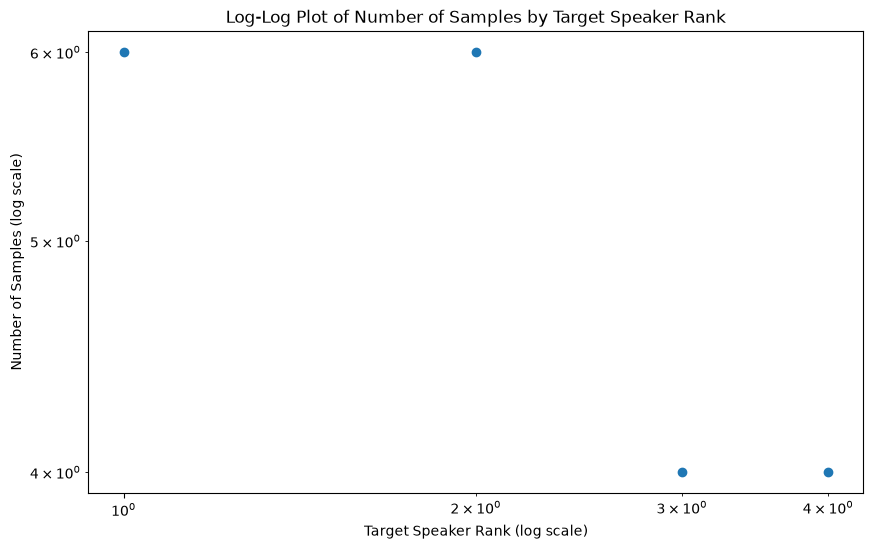

In [71]:
# log log plot of distribution of number of samples for target speaker rank
sorted_counts = sorted(number_by_target_speaker.items(), key=lambda x: x[1], reverse=True)
ranks = range(1, len(sorted_counts) + 1)
counts = [v for k, v in sorted_counts]
plt.figure(figsize=(10, 6))
plt.loglog(ranks, counts, marker='o', linestyle='None')
plt.xlabel('Target Speaker Rank (log scale)')
plt.ylabel('Number of Samples (log scale)')
plt.title('Log-Log Plot of Number of Samples by Target Speaker Rank')
plt.show()

## 2. Timing and overlap
### 2.1 `mixture_length_s`, `target_onset_s`, `interferer_onset_s`, `target_speech_s`, `target_activity`, `interferer_speech_s`, `interferer_activity`, `overlap_requested`, `overlap_achieved`

These columns are created using the following parameters to determine where the target will be speaking, for how long they will be speaking, where the interferer will speak, for how long will there be overlap between interefer and target:

- $\texttt{target\_activity\_ratio}: 0.75$ which is the goal for how long the target should ideally be speaking in the sample. This is the value that the paper $\textit{`REAL-TSE'}$ aimed for.
- $\texttt{activity\_tolerance}: 0.1$ how far above the goal the generator is allowed to land. Speech is built from WHOLE utterances, so there will be cases where we have longer speech so we have a range from 0.75-0.85 as a window. We will never consider lower.
- $\texttt{overlap\_ratio}: [0.2, 0.7]$ is drawn uniformly and represents the fraction of the window where both people are talking.
- $\texttt{overlap\_tolerance}: 0.03$ used for the interferer which is slid along the window to hit the requested overlap. 
- $\texttt{max\_utterances\_per\_source}: 8$ is the max number of consecutive utterances to make one speaker's speech, sp a source is never assembled from a long string of tiny fragments.

Therefore all of these columns are not independant draws and constrain each other arithmetically.


A big note, we only use one block to interfere with the target and not many places of interference. This does help simplify the train task, however, it does cost us realism. The hope is that these individual instances will translate to the many times we call on the model.

In [72]:
# only consider trials with a target speaker. Absent target trials have overlap 0 by definition
present = D.df[D.df['target_absent'] == 0]
print(f"Percentage of trials with a target speaker: {len(present)/len(D.df)*100:.2f}%")

Percentage of trials with a target speaker: 100.00%


#### Structural asymmetry

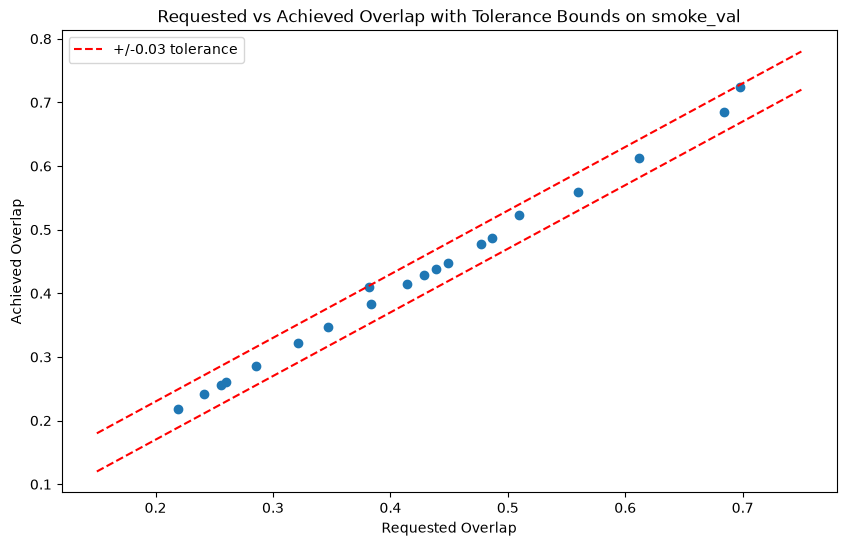

In [73]:
tolerance = D.cfg["overlap_tolerance"]
line = [0.15, 0.75]

plt.figure(figsize=(10, 6))
plt.scatter(present['overlap_requested'], present['overlap_achieved'])
plt.plot(line, [v + tolerance for v in line], color='red', linestyle='--', label=f'+/-{tolerance} tolerance')
plt.plot(line, [v - tolerance for v in line], color='red', linestyle='--')
plt.xlabel('Requested Overlap')
plt.ylabel('Achieved Overlap')
plt.title(f'Requested vs Achieved Overlap with Tolerance Bounds on {D.split}')
plt.legend()
plt.show()

In [74]:
miss = (present["overlap_achieved"] - present["overlap_requested"]).abs()
print(f"Worst miss: {miss.max():.4f}, Mean miss: {miss.mean():.4f}, Median miss: {miss.median():.4f}")
print(f"Acceptable hit percentages: {((miss <= tolerance).sum() / len(miss)) * 100:.2f}%")
print(f"Exact hit percentages: {((miss <= 1e-9).sum() / len(miss)) * 100:.2f}%")

Worst miss: 0.0280, Mean miss: 0.0037, Median miss: 0.0003
Acceptable hit percentages: 100.00%
Exact hit percentages: 10.00%


#### Activity, overlap and speech time

In [75]:
# activity 
difference = (present["target_activity"] - present["target_speech_s"]/ present["mixture_length_s"]).abs()
print(f"Worst activity difference: {difference.max():.4f}, Mean activity difference: {difference.mean():.4f}, Median activity difference: {difference.median():.4f}") 

Worst activity difference: 0.0001, Mean activity difference: 0.0000, Median activity difference: 0.0000


In [76]:
# speech time is sum of utterance durations
speech_time_diff = (present["target_speech_s"] - present["target_dur_list"].map(sum)).abs()
print(f"Worst speech time difference: {speech_time_diff.max():.4f}, Mean speech time difference: {speech_time_diff.mean():.4f}, Median speech time difference: {speech_time_diff.median():.4f}")  

Worst speech time difference: 0.0000, Mean speech time difference: 0.0000, Median speech time difference: 0.0000


In [77]:
# overlap is the shared time between two speaker talking intervals
worst = 0.0
for i, row in present.iterrows():
    shared_time = 0.0
    for t_start, t_end in spans(row, "target"):
        for i_start, i_end in spans(row, "interferer"):
            shared_time += max(0, min(t_end, i_end) - max(t_start, i_start))
    worst = max(worst, abs(shared_time / row["mixture_length_s"] - row["overlap_achieved"]))
print(f"Worst overlap difference: {worst:.4f}")

Worst overlap difference: 0.0001


Make a timeline plot for the first 3 trials with a target speaker, showing the target and interferer utterances as horizontal bars.

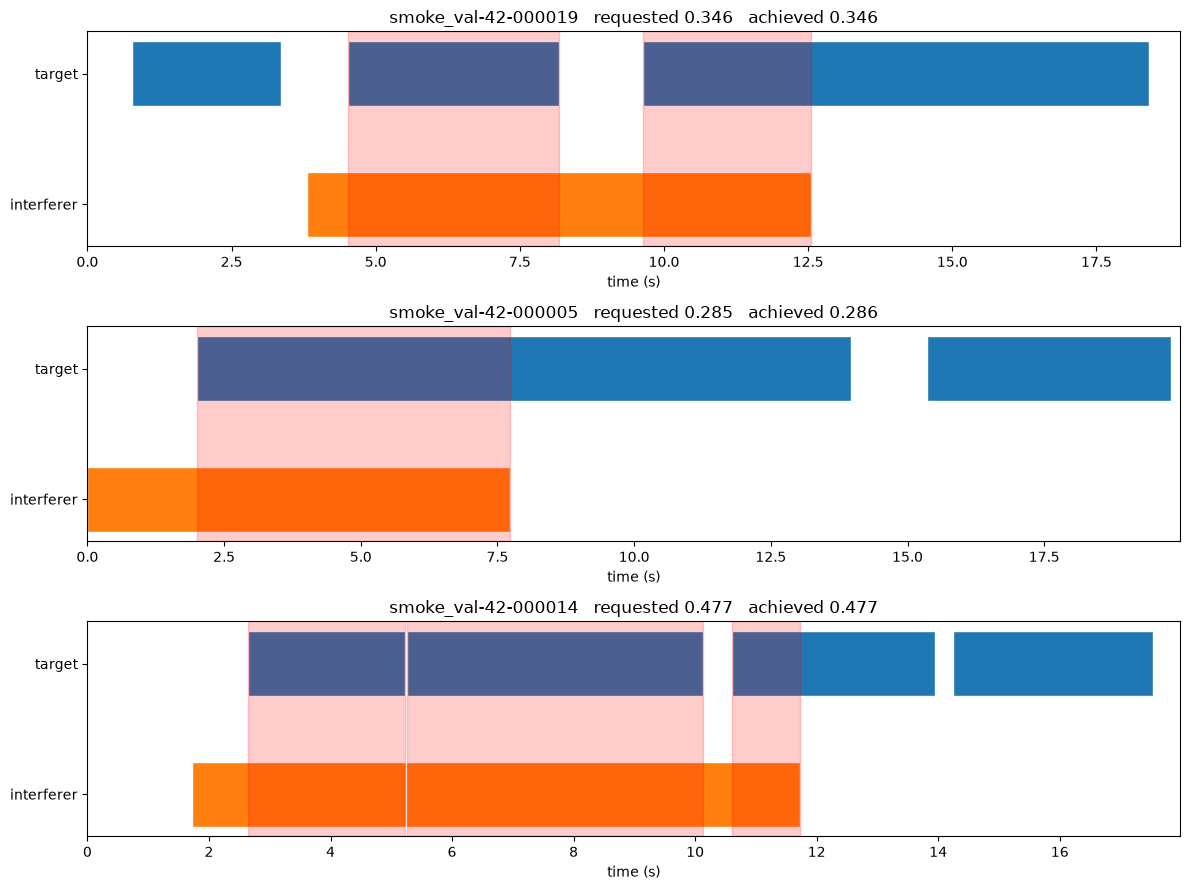

In [78]:
rows = 3

fig, axes = plt.subplots(rows, 1, figsize=(12, 3 * rows))
if rows == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    random_index = np.random.choice(D.df.index)
    row = D.df.iloc[random_index]

    # target bars on the top row, interferer underneath.
    # white edges so back-to-back utterances stay visible as separate blocks.
    for start, end in spans(row, "target"):
        ax.barh(1, end - start, left=start, height=0.5,
                color="tab:blue", edgecolor="white")
    for start, end in spans(row, "interferer"):
        ax.barh(0, end - start, left=start, height=0.5,
                color="tab:orange", edgecolor="white")

    # shade every stretch where both are talking
    for t_start, t_end in spans(row, "target"):
        for i_start, i_end in spans(row, "interferer"):
            lo, hi = max(t_start, i_start), min(t_end, i_end)
            if hi > lo:
                ax.axvspan(lo, hi, color="red", alpha=0.2)

    ax.set_xlim(0, row["mixture_length_s"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["interferer", "target"])
    
    # Only label x-axis on the bottom plot to reduce clutter, or keep on all
    ax.set_xlabel("time (s)")
    ax.set_title(f"{row['trial_id']}   requested {row['overlap_requested']:.3f}   "
                 f"achieved {row['overlap_achieved']:.3f}")

plt.tight_layout()
plt.show()
